# Notebook 2 — Weak Form and Element Assembly in 1D

In this notebook, we move from interpolation to the **finite element equations**.

We will study the boundary-value problem

$$
-u''(x)=f(x), \quad x\in[0,1], \qquad u(0)=u(1)=0.
$$

Our goals are:

1. understand the **weak form**
2. derive the **element stiffness matrix**
3. see how local element matrices are assembled into a global system

## 1. Why the weak form?

The differential equation is

$$
-u''(x)=f(x).
$$

Instead of solving this directly, we multiply by a test function $v(x)$ and integrate:

$$
\int_0^1 -u''(x)\,v(x)\,dx = \int_0^1 f(x)\,v(x)\,dx.
$$

Now integrate the left-hand side by parts:

$$
\int_0^1 u'(x)\,v'(x)\,dx = \int_0^1 f(x)\,v(x)\,dx.
$$

This is the **weak form**.

It is useful because:

- the second derivative disappears
- piecewise linear basis functions are now enough
- the equation is naturally written in integral form

## 2. Finite element approximation

We approximate the solution by

$$
u_h(x)=\sum_{j=0}^n U_j \phi_j(x),
$$

where:

- $\phi_j(x)$ are the hat functions
- $U_j$ are unknown nodal coefficients

Using the same basis functions as test functions gives the discrete system

$$
\sum_{j=0}^n U_j \int_0^1 \phi_j'(x)\phi_i'(x)\,dx
=
\int_0^1 f(x)\phi_i(x)\,dx.
$$

This becomes the matrix equation

$$
KU = F.
$$

## 3. One linear element

Consider one element $[x_1,x_2]$ with length

$$
h=x_2-x_1.
$$

On this element, the local basis functions are

$$
N_1(x)=\frac{x_2-x}{h}, \qquad
N_2(x)=\frac{x-x_1}{h}.
$$

Their derivatives are constant:

$$
N_1'(x)=-\frac{1}{h}, \qquad N_2'(x)=\frac{1}{h}.
$$

The local element stiffness matrix is

$$
K^{(e)}_{ij} = \int_{x_1}^{x_2} N_i'(x)N_j'(x)\,dx.
$$

This gives

$$
K^{(e)} = \frac{1}{h}
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}.
$$

In [1]:
import numpy as np

h = 0.2
Ke = (1.0 / h) * np.array([[1, -1],
                           [-1, 1]])
Ke

array([[ 5., -5.],
       [-5.,  5.]])

## 4. Local force vector

If the right-hand side is $f(x)$, then the local load vector is

$$
F^{(e)}_i = \int_{x_1}^{x_2} f(x)N_i(x)\,dx.
$$

For the simple case $f(x)=1$, the result is

$$
F^{(e)} = \frac{h}{2}
\begin{bmatrix}
1 \\
1
\end{bmatrix}.
$$

In [2]:
Fe = (h / 2.0) * np.array([1.0, 1.0])
Fe

array([0.1, 0.1])

## 5. Assembly idea

Each element contributes its local matrix and local vector to the correct positions in the global matrix and vector.

For example, if one element connects global nodes $[2,3]$, then

$$
K[2:4,\,2:4] \mathrel{+}= K^{(e)}.
$$

This is called **assembly**.

In [3]:
# Small example with 4 elements and 5 nodes
n_elements = 4
n_nodes = n_elements + 1
x_nodes = np.linspace(0.0, 1.0, n_nodes)
h = x_nodes[1] - x_nodes[0]

Ke = (1.0 / h) * np.array([[1, -1],
                           [-1, 1]])
Fe = (h / 2.0) * np.array([1.0, 1.0])

K = np.zeros((n_nodes, n_nodes))
F = np.zeros(n_nodes)

for e in range(n_elements):
    nodes = [e, e + 1]
    K[np.ix_(nodes, nodes)] += Ke
    F[nodes] += Fe

print("Global stiffness matrix K:")
print(K)

print("\nGlobal force vector F:")
print(F)

Global stiffness matrix K:
[[ 4. -4.  0.  0.  0.]
 [-4.  8. -4.  0.  0.]
 [ 0. -4.  8. -4.  0.]
 [ 0.  0. -4.  8. -4.]
 [ 0.  0.  0. -4.  4.]]

Global force vector F:
[0.125 0.25  0.25  0.25  0.125]


## 6. Visualizing the sparsity pattern

The global matrix is mostly zeros because each basis function interacts only with nearby basis functions.

That is why FEM matrices are usually **sparse**.

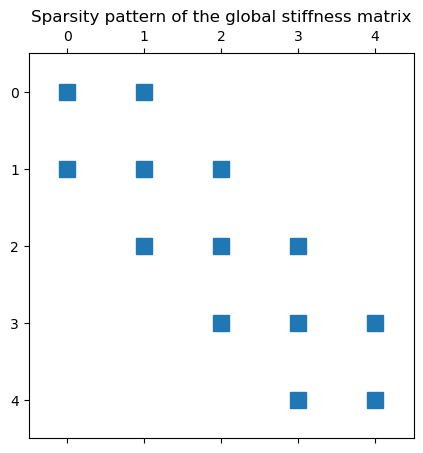

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.spy(K, markersize=12)
plt.title("Sparsity pattern of the global stiffness matrix")
plt.show()

## 7. Meaning of the matrix entries

Each entry of the matrix is

$$
K_{ij} = \int_0^1 \phi_j'(x)\phi_i'(x)\,dx.
$$

For linear elements in 1D:

- $K_{ii}$ gets positive contributions from neighboring elements
- $K_{i,i\pm 1}$ gets negative contributions
- distant basis functions do not overlap, so the entries are zero

## 8. Boundary conditions

The problem has homogeneous Dirichlet conditions:

$$
u(0)=0, \qquad u(1)=0.
$$

So the nodal values at the two end points are known:

$$
U_0=0, \qquad U_n=0.
$$

This means that only the **interior unknowns** need to be solved for.

In [5]:
# Interior system after applying u(0)=u(1)=0
free = np.arange(1, n_nodes - 1)

K_reduced = K[np.ix_(free, free)]
F_reduced = F[free]

print("Reduced stiffness matrix:")
print(K_reduced)

print("\nReduced force vector:")
print(F_reduced)

Reduced stiffness matrix:
[[ 8. -4.  0.]
 [-4.  8. -4.]
 [ 0. -4.  8.]]

Reduced force vector:
[0.25 0.25 0.25]


## 9. Physical picture

For this simple 1D problem:

- the stiffness matrix comes from the derivatives of the basis functions
- the load vector comes from the source term $f(x)$
- assembly adds element contributions into a global balance
- boundary conditions reduce the unknowns

The next step is to solve the system and compare with the exact solution.

## Summary

In this notebook, we learned that:

- the weak form replaces the second derivative problem with an integral equation
- each element has a small local stiffness matrix
- local matrices are assembled into a global sparse matrix
- Dirichlet boundary conditions reduce the system to interior unknowns

The next notebook will solve the full 1D problem in Python.